In [2]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [3]:
ls

sample_data/


In [4]:
!git clone https://github.com/OpenDriveLab/DriveLM.git

Cloning into 'DriveLM'...
remote: Enumerating objects: 6152, done.
remote: Counting objects: 100% (548/548), done.
remote: Compressing objects: 100% (264/264), done.
remote: Total 6152 (delta 390), reused 313 (delta 283), pack-reused 5604 (from 2)
Receiving objects: 100% (6152/6152), 280.55 MiB | 34.16 MiB/s, done.
Resolving deltas: 100% (3006/3006), done.


In [5]:
ls DriveLM

assets/     CITATION.cff        docs/            index.html  README.md
challenge/  CODE_OF_CONDUCT.md  environment.yml  LICENSE     sample.html


In [7]:
!find DriveLM/challenge -type f | head -50

DriveLM/challenge/llama_adapter_v2_multimodal7b/finetune_data_config.yaml
DriveLM/challenge/llama_adapter_v2_multimodal7b/exps/finetune.sh
DriveLM/challenge/llama_adapter_v2_multimodal7b/exps/pretrain.sh
DriveLM/challenge/llama_adapter_v2_multimodal7b/requirements.txt
DriveLM/challenge/llama_adapter_v2_multimodal7b/engine_finetune.py
DriveLM/challenge/llama_adapter_v2_multimodal7b/llama/tokenizer.py
DriveLM/challenge/llama_adapter_v2_multimodal7b/llama/llama_adapter.py
DriveLM/challenge/llama_adapter_v2_multimodal7b/llama/utils.py
DriveLM/challenge/llama_adapter_v2_multimodal7b/llama/__init__.py
DriveLM/challenge/llama_adapter_v2_multimodal7b/llama/llama.py
DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_BACK_RIGHT/n008-2018-09-18-13-10-39-0400__CAM_BACK_RIGHT__1537291005178113.jpg
DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_BACK_RIGHT/n015-2018-08-03-15-00-36+0800__CAM_BACK_RIGHT__1533280045127893.jpg
DriveLM/challenge/llama_adap

In [8]:
!find DriveLM/assets -type f | head -50

DriveLM/assets/images/svg/featured.svg
DriveLM/assets/images/svg/divider.svg
DriveLM/assets/images/svg/faq.svg
DriveLM/assets/images/svg/graphic-2.svg
DriveLM/assets/images/svg/pin.svg
DriveLM/assets/images/svg/pattern-lg-light.svg
DriveLM/assets/images/svg/pin-light.svg
DriveLM/assets/images/svg/pattern.svg
DriveLM/assets/images/svg/dialog.svg
DriveLM/assets/images/svg/master-card-1.svg
DriveLM/assets/images/svg/quotes.svg
DriveLM/assets/images/svg/pattern-lg.svg
DriveLM/assets/images/svg/shadow.svg
DriveLM/assets/images/svg/404.svg
DriveLM/assets/images/svg/featured-light.svg
DriveLM/assets/images/svg/visa-1.svg
DriveLM/assets/images/svg/graphic-1.svg
DriveLM/assets/images/logo/opendrivelab.jpeg
DriveLM/assets/images/logo/tubingen.jpeg
DriveLM/assets/images/page/front_page_dark.png
DriveLM/assets/images/page/front_page.png
DriveLM/assets/images/page/video_front_page.png
DriveLM/assets/images/page/galaxy.jpeg
DriveLM/assets/images/repo/title.jpg
DriveLM/assets/images/repo/paper_teaser

In [9]:
!find DriveLM/docs -type f | head -50

DriveLM/docs/data_prep_nus.md
DriveLM/docs/gvqa.md
DriveLM/docs/data_details.md


In [10]:
!find DriveLM -name "*.json" | head -100

DriveLM/challenge/test_eval.json
DriveLM/challenge/test_llama.json
DriveLM/challenge/output.json
DriveLM/challenge/data/train_sample.json
DriveLM/challenge/test.json
DriveLM/challenge/submission.json


In [11]:
!find DriveLM -name "*.jsonl" | head -100

In [6]:
import json

with open("DriveLM/challenge/data/train_sample.json", "r") as f:
    data = json.load(f)

print(type(data))
print(len(data))

# Show first record
print(data[0] if isinstance(data, list) else list(data.keys())[:10])

<class 'dict'>
2
['f0f120e4d4b0441da90ec53b16ee169d', '54cdaaae372d421fa4734d66f51a8c48']


In [7]:
first_key = list(data.keys())[0]

print("First Key:", first_key)
print(type(data[first_key]))
print(data[first_key])

First Key: f0f120e4d4b0441da90ec53b16ee169d
<class 'dict'>
{'scene_description': 'The ego vehicle proceeds through the intersection, continuing along the current roadway.', 'key_frames': {'4a0798f849ca477ab18009c3a20b7df2': {'key_object_infos': {'<c1,CAM_BACK,1088.3,497.5>': {'Category': 'Vehicle', 'Status': 'Moving', 'Visual_description': 'Brown SUV.', '2d_bbox': [966.6, 403.3, 1224.1, 591.7]}, '<c2,CAM_BACK,864.2,468.3>': {'Category': 'Vehicle', 'Status': 'Moving', 'Visual_description': 'Black sedan.', '2d_bbox': [816.7, 431.6, 917.2, 505.0]}, '<c3,CAM_FRONT,1043.2,82.2>': {'Category': 'Traffic element', 'Status': None, 'Visual_description': 'Green light.', '2d_bbox': [676.4, 0.0, 1452.6, 171.5]}}, 'QA': {'perception': [{'Q': 'What are objects to the front right of the ego car?', 'A': 'There are many barriers and one construction vehicle to the front right of the ego car.', 'C': None, 'con_up': None, 'con_down': None, 'cluster': None, 'layer': None}, {'Q': 'What are objects to the fr

In [8]:
import json

with open("DriveLM/challenge/data/train_sample.json") as f:
    data = json.load(f)

print("Scenes:", len(data))

first_scene = list(data.keys())[0]

print("Scene ID:", first_scene)

scene = data[first_scene]

print("\nTop Level Keys:")
print(scene.keys())

Scenes: 2
Scene ID: f0f120e4d4b0441da90ec53b16ee169d

Top Level Keys:
dict_keys(['scene_description', 'key_frames'])


In [9]:
first_scene = list(data.keys())[0]
scene = data[first_scene]

print("Number of key frames:", len(scene["key_frames"]))

first_frame = list(scene["key_frames"].keys())[0]

print("First frame:", first_frame)

frame = scene["key_frames"][first_frame]

print("\nFrame Keys:")
print(frame.keys())

Number of key frames: 4
First frame: 4a0798f849ca477ab18009c3a20b7df2

Frame Keys:
dict_keys(['key_object_infos', 'QA', 'image_paths'])


In [10]:
import json
import pandas as pd

with open("DriveLM/challenge/data/train_sample.json") as f:
    data = json.load(f)

records = []

for scene_id, scene_data in data.items():

    scene_desc = scene_data["scene_description"]

    for frame_id, frame_data in scene_data["key_frames"].items():

        image_paths = frame_data["image_paths"]

        qa_data = frame_data["QA"]

        for qa_category, qa_list in qa_data.items():

            for qa in qa_list:

                records.append({
                    "scene_id": scene_id,
                    "frame_id": frame_id,
                    "scene_description": scene_desc,
                    "qa_category": qa_category,
                    "question": qa["Q"],
                    "answer": qa["A"],
                    "cam_front": image_paths.get("CAM_FRONT")
                })

df = pd.DataFrame(records)

print("Rows:", len(df))
print(df.head())

Rows: 790
                           scene_id                          frame_id  \
0  f0f120e4d4b0441da90ec53b16ee169d  4a0798f849ca477ab18009c3a20b7df2   
1  f0f120e4d4b0441da90ec53b16ee169d  4a0798f849ca477ab18009c3a20b7df2   
2  f0f120e4d4b0441da90ec53b16ee169d  4a0798f849ca477ab18009c3a20b7df2   
3  f0f120e4d4b0441da90ec53b16ee169d  4a0798f849ca477ab18009c3a20b7df2   
4  f0f120e4d4b0441da90ec53b16ee169d  4a0798f849ca477ab18009c3a20b7df2   

                                   scene_description qa_category  \
0  The ego vehicle proceeds through the intersect...  perception   
1  The ego vehicle proceeds through the intersect...  perception   
2  The ego vehicle proceeds through the intersect...  perception   
3  The ego vehicle proceeds through the intersect...  perception   
4  The ego vehicle proceeds through the intersect...  perception   

                                            question  \
0  What are objects to the front right of the ego...   
1  What are objects to the fro

In [11]:
df["qa_category"].value_counts()

,count
qa_category,
perception,337
prediction,271
planning,173
behavior,9


In [12]:
df["question_length"] = df["question"].apply(lambda x: len(str(x).split()))

df["question_length"].describe()

,question_length
count,790.000000
mean,13.956962
std,13.028220
min,4.000000
25%,9.000000
50%,12.000000
75%,16.000000
max,113.000000


In [13]:
df["question_length"].describe()

,question_length
count,790.000000
mean,13.956962
std,13.028220
min,4.000000
25%,9.000000
50%,12.000000
75%,16.000000
max,113.000000


In [14]:
df["answer_length"].describe()

KeyError: 'answer_length'

In [15]:
df["answer_length"] = df["answer"].apply(lambda x: len(str(x).split()))

df["answer_length"].describe()

,answer_length
count,790.000000
mean,7.049367
std,13.305853
min,1.000000
25%,1.000000
50%,2.000000
75%,9.000000
max,174.000000


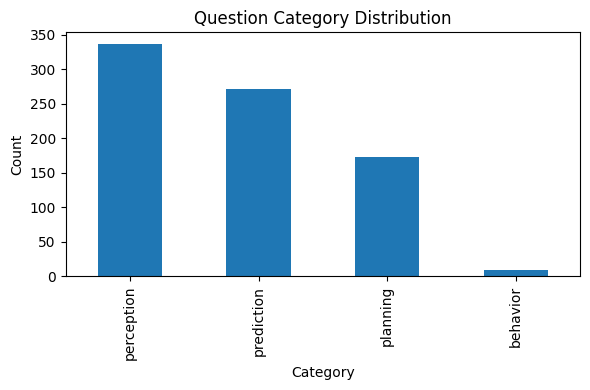

In [16]:
import matplotlib.pyplot as plt

category_counts = df["qa_category"].value_counts()

plt.figure(figsize=(6,4))
category_counts.plot(kind="bar")
plt.title("Question Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [17]:
df.to_csv("processed_dataset.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully


In [26]:
ls

DriveLM/  processed_dataset.csv  sample_data/


In [18]:
!du -sh DriveLM/challenge/data

400K	DriveLM/challenge/data


In [19]:
!ls DriveLM/challenge/data

train_sample.json


In [20]:
!du -sh DriveLM/challenge/data
!ls DriveLM/challenge/data

400K	DriveLM/challenge/data
train_sample.json


In [21]:
!cat DriveLM/docs/data_details.md

## Features of the DriveLM-Data <a name="features"></a>

- 🛣 Completeness in functionality (covering **Perception**, **Prediction**, and **Planning** QA pairs).


<p align="center">
  <img src="../assets/images/repo/point_1.png">
</p>


- 🔜 Reasoning for future events that have not yet happened.
  - Many **"What If"**-style questions: imagine the future by language.
 

<p align="center">
  <img src="../assets/images/repo/point_2.png" width=70%>
</p>

- ♻ Task-driven decomposition.
  - **One** scene-level description into **many** frame-level trajectories & planning QA pairs.

<p align="center">
  <img src="../assets/images/repo/point_3.png">
</p>

## How about the annotation process? <a name="annotation"></a>

The annotation process is different for DriveLM-nuScenes and DriveLM-CARLA.

<p align="center">
  <img src="../assets/images/repo/paper_data.jpg">
</p>

**For DriveLM-nuScenes**, we divide the annotation process into three steps:

1️⃣ Keyframe selection. Given all frames in one c

In [22]:
!grep -R "download" DriveLM/docs -n
!grep -R "huggingface" DriveLM -n
!grep -R "opendatalab" DriveLM -n

DriveLM/docs/data_prep_nus.md:2:We kindly hope you to fill out the [form](https://docs.google.com/forms/d/e/1FAIpQLSeX6CR3u-15IV-TKx2uPv1wiKjydjZ__NNW98H4nR5JZtQa2Q/viewform) before downloading. To get started, download nuScenes subset image data and DriveLM-nuScenes QA json files below. For v1.1 data, please visit the [DriveLM/challenge](https://github.com/OpenDriveLab/DriveLM/tree/main/challenge) folder.
DriveLM/docs/data_prep_nus.md:14:You can also download the full nuScenes dataset [HERE](https://www.nuscenes.org/download) to enable video input. 
DriveLM/challenge/llama_adapter_v2_multimodal7b/docs/train.md:46:  | llava_instruct_150k.json | [File Link](https://huggingface.co/datasets/liuhaotian/LLaVA-Instruct-150K/raw/main/llava_instruct_150k.json)   |
DriveLM/challenge/llama_adapter_v2_multimodal7b/gradio_app.py:83:The demo for **LLaMA-Adapter V1** is available at: [Huggingface Spaces](https://huggingface.co/spaces/csuhan/LLaMA-Adapter).
DriveLM/challenge/README.md:35:|[HuggingFac

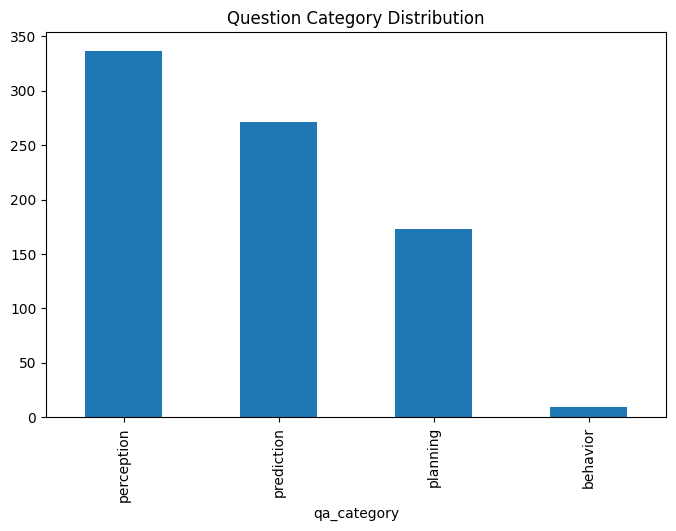

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["qa_category"].value_counts().plot(kind="bar")
plt.title("Question Category Distribution")
plt.show()

In [24]:
df.to_csv("processed_dataset.csv", index=False)

In [25]:
df["answer_length"] = df["answer"].apply(lambda x: len(str(x).split()))

print(df["answer_length"].describe())

count    790.000000
mean       7.049367
std       13.305853
min        1.000000
25%        1.000000
50%        2.000000
75%        9.000000
max      174.000000
Name: answer_length, dtype: float64


In [27]:
!find DriveLM -name "*1537291010612404.jpg"

DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg
